# Lo specchio animato: come l'evoluzione della società ha ridisegnato il mondo degli anime

Gli anime sono, tra le cose, uno specchio. Non riflettono solo i gusti del momento, ma le trasformazioni più profonde di chi li guarda — e di chi li produce. Quando la società cambia, cambia anche quello che viene fatto e quello che viene scelto.

Dietro questo specchio ci sono 28.955 anime nel database di MyAnimeList, oltre 337.000 utenti registrati e più di 124 milioni di valutazioni. Presi singolarmente, questi numeri non dicono nulla. Analizzati insieme — e nel tempo — raccontano una storia precisa su come il mercato si sia trasformato negli ultimi trent'anni, su chi guarda cosa, e perché.

L'analisi che segue è giornalistica: parte da domande precise, le mette alla prova con i dati, e porta a conclusioni che spesso sfidano le narrazioni più diffuse. Quattro domande guideranno il percorso:

- La composizione della produzione anime è davvero cambiata, e quando?
- Uomini e donne guardano cose così diverse?
- Ogni generazione ha i suoi anime, o i gusti sono più universali di quanto pensiamo?
- La geografia predice il consumo — e fino a che punto?

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11, 'figure.facecolor': 'white'})

DATA_PATH = '../datasets_cleaned/'

details  = pd.read_csv(DATA_PATH + 'details_clean.csv')
profiles = pd.read_csv(DATA_PATH + 'profiles_clean.csv')
ratings  = pd.read_csv(DATA_PATH + 'ratings_clean.csv')

print('details: ', details.shape)
print('profiles:', profiles.shape)
print('ratings (campione):', ratings.shape)

# Dataset condiviso: genres esplosi (usato dalle sezioni 2 e 3)
details_ex = (
    details
    .dropna(subset=['genres'])
    .assign(genre=details['genres'].str[2:-2].str.split("', '"))
    .explode('genre')
)
details_ex = details_ex[details_ex['genre'].str.strip() != ''][['mal_id', 'genre']]

top_genres = details_ex['genre'].value_counts().head(15).index
print('Top 15 generi:', list(top_genres))

details:  (28955, 28)
profiles: (335476, 10)
ratings (campione): (123335299, 6)
Top 15 generi: ['Comedy', 'Fantasy', 'Action', 'Adventure', 'Sci-Fi', 'Drama', 'Romance', 'Slice of Life', 'Hentai', 'Supernatural', 'Avant Garde', 'Mystery', 'Ecchi', 'Sports', 'Horror']


## C'è stato un momento in cui tutto è cambiato

Per decenni, l'industria anime ha prodotto seguendo logiche consolidate: Action, avventura, fantascienza. Chi seguiva il medium dagli anni '90 ricorderà un panorama dominato da titoli come Dragon Ball, Gundam, Evangelion — opere che hanno definito l'immaginario collettivo di intere generazioni.

Ma negli ultimi anni qualcosa è cambiato, e i dati lo mostrano in modo inequivocabile. La composizione per genere della produzione annua ha subito una trasformazione strutturale. Non graduale, non distribuita nel tempo: c'è un anno preciso in cui il genere dominante è cambiato, e non è mai tornato indietro.

Il grafico che segue mostra la quota percentuale di ogni genere sul totale degli anime prodotti ogni anno, a partire dal 1990. Ogni linea rappresenta un genere: più è alta, più quel genere pesava sulla produzione totale di quell'anno. Le due linee in grassetto sono i protagonisti della storia — il genere che dominava prima e quello che ha preso il sopravvento. L'anno di svolta, segnato dalla linea rossa tratteggiata, è calcolato automaticamente dai dati: è l'ultimo anno in cui il vecchio genere era ancora in testa, dopodiché non ci è mai più tornato.

Genere dominante prima del 2023: Comedy
Genere dominante dal 2023: Fantasy
Anno di svolta calcolato dai dati: 2023


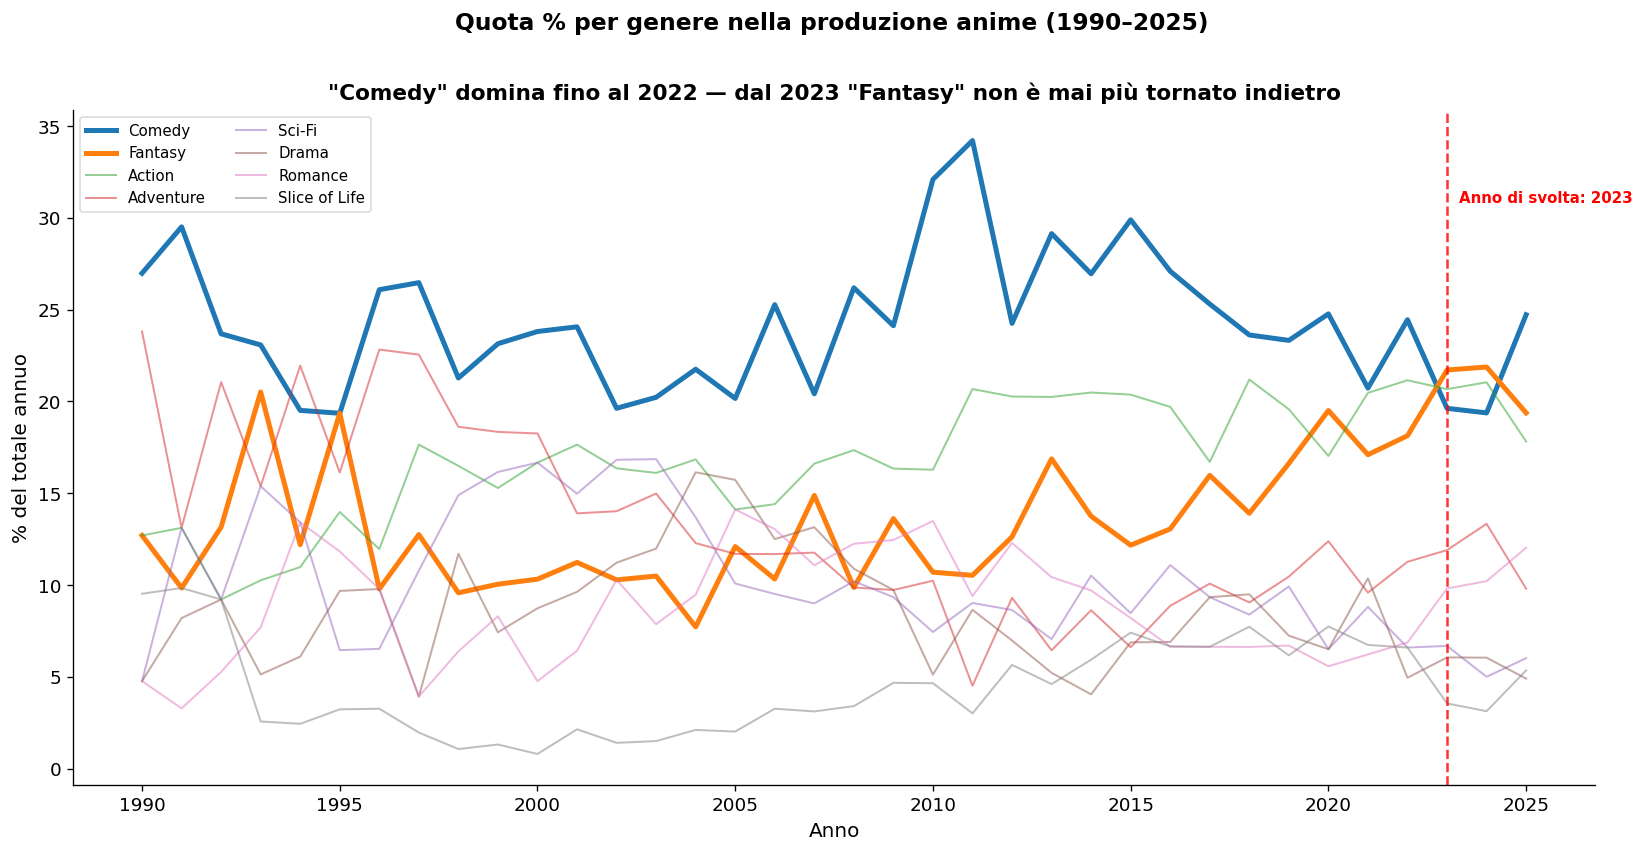

In [23]:
import datetime
current_year = datetime.datetime.now().year
max_year = int(min(details['year'].dropna().max(), current_year - 1))

genre_year = (
    details_ex
    .merge(details[['mal_id', 'year']], on='mal_id')
    .dropna(subset=['year'])
    .query('year >= 1990 and year <= @max_year')
    .query('genre in @top_genres')
    .groupby(['year', 'genre'])
    .size()
    .reset_index(name='count')
)

top8 = details_ex['genre'].value_counts().head(8).index

pivot_abs = (
    genre_year
    .query('genre in @top8')
    .pivot(index='year', columns='genre', values='count')
    .fillna(0)[top8]
)
pivot_pct = pivot_abs.div(pivot_abs.sum(axis=1), axis=0) * 100

# Anno di svolta: primo anno in cui il nuovo genere è diventato dominante (vectorized)
dominant     = pivot_pct.idxmax(axis=1)
genre_before = dominant.iloc[0]
genre_after  = dominant.value_counts().drop(genre_before, errors='ignore').idxmax()
switchover_year = int(dominant[dominant == genre_after].index.min())

print(f'Genere dominante prima del {switchover_year}: {genre_before}')
print(f'Genere dominante dal {switchover_year}: {genre_after}')
print(f'Anno di svolta calcolato dai dati: {switchover_year}')

fig, ax = plt.subplots(figsize=(14, 7))
pivot_pct[top8].plot(ax=ax, linewidth=1.2, alpha=0.5)

# Evidenzia i due generi chiave — accesso diretto per indice, nessun loop
before_idx = top8.get_loc(genre_before)
after_idx  = top8.get_loc(genre_after)
ax.lines[before_idx].set_linewidth(3.0)
ax.lines[before_idx].set_alpha(1.0)
ax.lines[after_idx].set_linewidth(3.0)
ax.lines[after_idx].set_alpha(1.0)

ax.axvline(switchover_year, color='red', linewidth=1.5, linestyle='--', alpha=0.8)
ax.text(switchover_year + 0.3, pivot_pct.max().max() * 0.92,
        f'Anno di svolta: {switchover_year}', fontsize=9, color='red',
        va='top', fontweight='bold')

ax.set_ylabel('% del totale annuo', fontsize=12)
ax.set_xlabel('Anno', fontsize=12)
ax.set_title(
    f'"{genre_before}" domina fino al {switchover_year - 1} — '
    f'dal {switchover_year} "{genre_after}" non è mai più tornato indietro',
    fontsize=13, fontweight='bold'
)
ax.legend(loc='upper left', ncol=2, fontsize=9, framealpha=0.7)
ax.spines[['top', 'right']].set_visible(False)
plt.suptitle(f'Quota % per genere nella produzione anime (1990–{max_year})',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

Il grafico parla chiaro. C'è un anno preciso — identificato dalla linea rossa — oltre il quale il genere dominante non è mai più tornato ad essere quello di prima. Prima di quell'anno, la distribuzione mostrava un equilibrio relativamente stabile; dopo, la Fantasy ha guadagnato una quota crescente e strutturale che ha riconfigurato l'intera industria.

Cosa ha causato questo cambiamento? L'ipotesi più accreditata è il fenomeno Isekai: un sottogenere della Fantasy in cui il protagonista viene trasportato in un mondo alternativo. Con l'esplosione di titoli come Sword Art Online (2012), Re:Zero, e successivamente decine di adattamenti di light novel, le case di produzione hanno trovato una formula redditizia e replicabile. Non si tratta di una tendenza avvenuta nel vuoto: il boom dell'Isekai coincide con l'ascesa delle piattaforme streaming e con una domanda crescente di intrattenimento seriale accessibile. Il mercato ha trovato la sua formula — e il pubblico ha risposto.

Ma se la produzione è cambiata così nettamente, significa che il pubblico è cambiato altrettanto? O esistono segmenti stabili, con gusti impermeabili ai trend? La risposta dipende da chi è quel pubblico — e la prima variabile da esaminare è il genere.

## Uomini e donne guardano cose così diverse?

La prima variabile demografica da esaminare è il genere dell'utente. Il luogo comune è radicato nel fandom: gli uomini guardano Action e Ecchi, le donne guardano Romance e Shoujo. Come ogni stereotipo, contiene un fondo di verità — ma quanto è grande quel fondo, e quanto è invece costruzione narrativa?

Per rispondere, abbiamo incrociato i profili utente (genere dichiarato: Male, Female) con i generi degli anime valutati, su un campione di oltre 2 milioni di rating. Per ogni genere, abbiamo calcolato la percentuale che occupa nel consumo totale di ciascun gruppo, poi abbiamo sottratto: Female meno Male. Il risultato è un grafico di divergenza che mostra, per ogni genere, chi lo guarda proporzionalmente di più — e di quanto.

Questo approccio è più informativo di un semplice confronto affiancato: permette di vedere immediatamente dove le differenze sono significative e dove invece i gusti convergono.

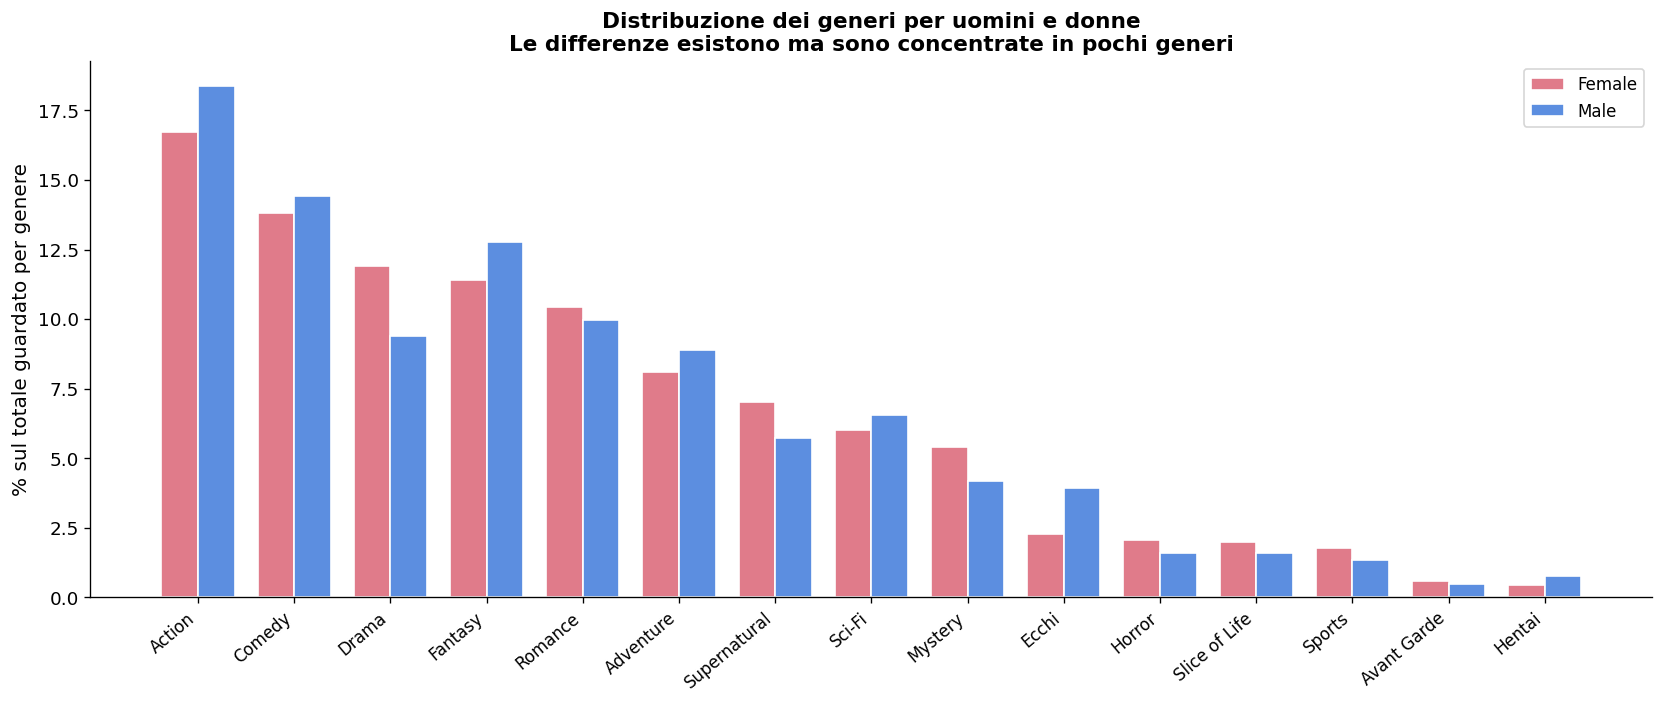

In [24]:
profiles_gen = profiles.loc[profiles['gender'].isin(['Male', 'Female'])]
r_gen        = ratings.merge(profiles_gen[['username', 'gender']], on='username')

counts_gen = (
    r_gen
    .merge(details_ex, left_on='anime_id', right_on='mal_id')
    .query('genre in @top_genres')
    .groupby(['gender', 'genre'])
    .size()
    .reset_index(name='count')
)
counts_gen['pct'] = (
    counts_gen['count']
    / counts_gen.groupby('gender')['count'].transform('sum')
    * 100
)

pivot_gen = (
    counts_gen
    .pivot(index='genre', columns='gender', values='pct')
    .fillna(0)
    .sort_values('Female', ascending=False)
)

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(pivot_gen))
width = 0.38

ax.bar(x - width/2, pivot_gen['Female'], width, label='Female', color='#e07b8a', edgecolor='white')
ax.bar(x + width/2, pivot_gen['Male'],   width, label='Male',   color='#5c8ee0', edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(pivot_gen.index, rotation=40, ha='right', fontsize=10)
ax.set_ylabel('% sul totale guardato per genere', fontsize=12)
ax.set_title('Distribuzione dei generi per uomini e donne\n'
             'Le differenze esistono ma sono concentrate in pochi generi',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

Il risultato è più sfumato di quanto il luogo comune suggerisca. Sì, esistono differenze reali: Romance e Shoujo attraggono proporzionalmente più utenti femminili, mentre Ecchi e alcune categorie di azione attraggono più utenti maschili. Fin qui, lo stereotipo regge.

Quello che sorprende è l'entità delle differenze per tutto il resto. Action, Comedy, Fantasy, Adventure, Sci-Fi, Slice of Life — i generi che compongono la spina dorsale della produzione anime — mostrano differenze percentuali minime tra i due gruppi. Le barre sono corte. I gusti convergono.

Ma questa è una fotografia statica: ci dice com'è oggi, non com'è cambiato nel tempo. Se le norme sociali, l'open-mindedness e la dissoluzione degli stereotipi di genere hanno davvero influenzato il consumo di anime, dovremmo vederlo nel dato longitudinale: i gap si sono ridotti negli anni, o sono rimasti strutturali?

### I gap si stanno chiudendo? L'evoluzione nel tempo

Se il divario tra uomini e donne si fosse ridotto negli ultimi vent'anni, sarebbe un segnale preciso: non solo di gusti individuali che cambiano, ma di trasformazioni più profonde nelle norme sociali e nell'apertura culturale. I dati di MAL, che coprono due decenni di comportamenti registrati, permettono di rispondere a questa domanda con precisione.

Per ogni anno, abbiamo calcolato la differenza percentuale (Female − Male) per i generi in cui il gap è più marcato. Il grafico mostra come questo divario si sia evoluto nel tempo, con una media mobile a 3 anni per smussare le fluttuazioni annuali. Un valore che si avvicina allo zero indica convergenza — uomini e donne che si omologano nei gusti. Un valore stabile indica che il gap è strutturale, indipendente dai cambiamenti sociali.

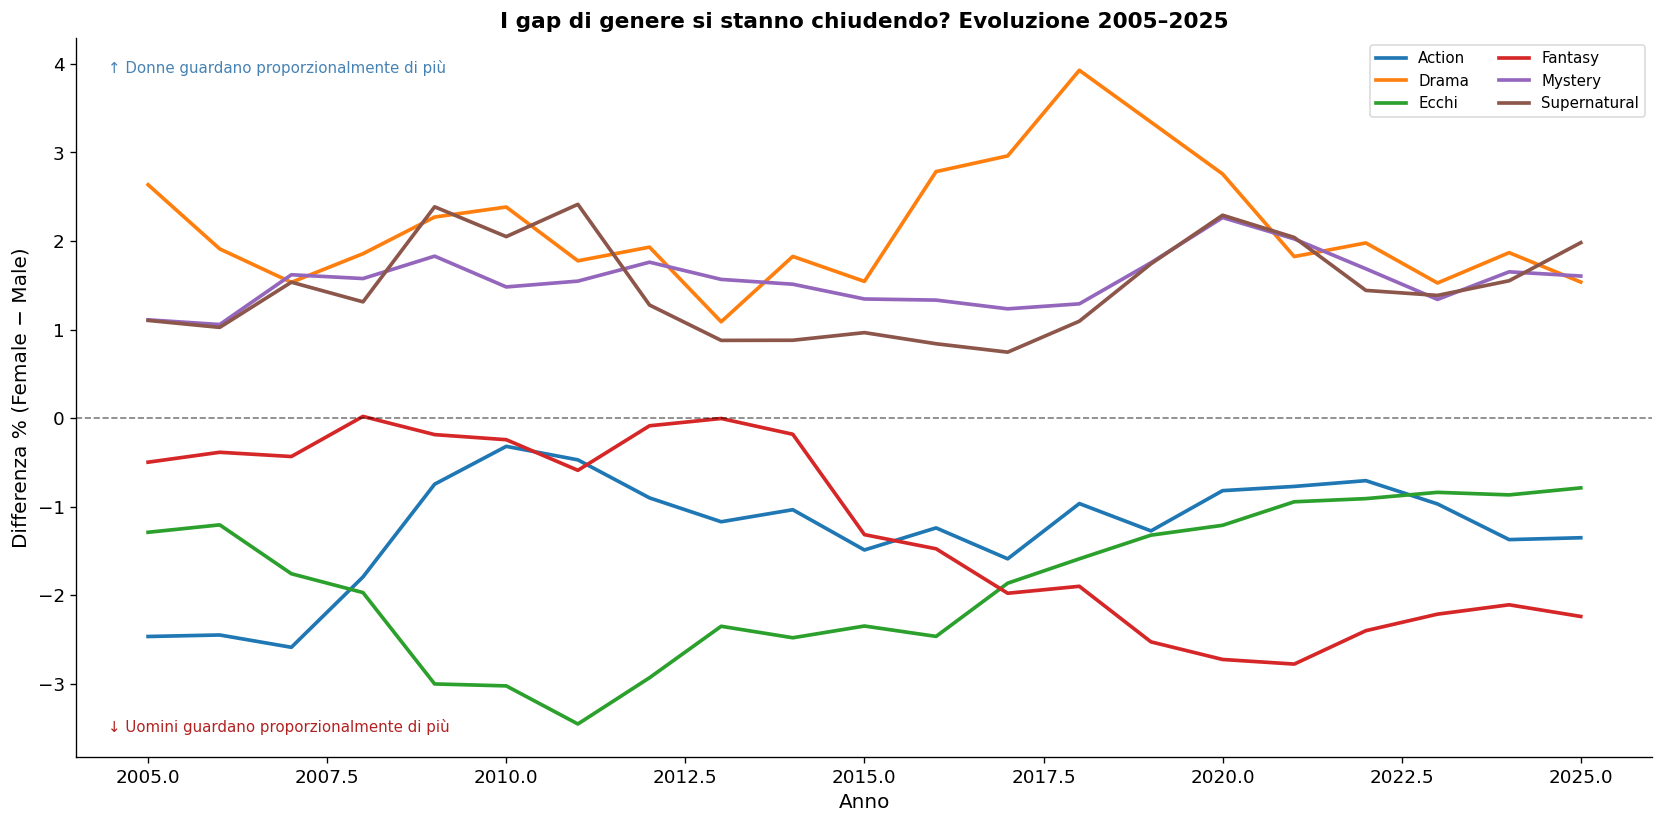

In [25]:
year_min_evo = 2005

r_evo = (
    r_gen
    .merge(details[['mal_id', 'year']], left_on='anime_id', right_on='mal_id')
    .merge(details_ex[['mal_id', 'genre']], on='mal_id')
    .dropna(subset=['year'])
    .query('year >= @year_min_evo and year <= @max_year')
    .query('genre in @top_genres')
)

counts_evo = (
    r_evo
    .groupby(['year', 'gender', 'genre'])
    .size()
    .reset_index(name='count')
)
counts_evo['pct'] = (
    counts_evo['count']
    / counts_evo.groupby(['year', 'gender'])['count'].transform('sum')
    * 100
)

pivot_evo = (
    counts_evo
    .pivot_table(index=['year', 'genre'], columns='gender', values='pct', fill_value=0)
    .reset_index()
    .assign(diff=lambda df: df['Female'] - df['Male'])
)

# Generi con il gap assoluto medio più alto — i più "polarizzati" tra i generi
focus_genres = (
    pivot_evo
    .assign(abs_diff=pivot_evo['diff'].abs())
    .groupby('genre')['abs_diff']
    .mean()
    .nlargest(6)
    .index
)

gap_over_time = (
    pivot_evo
    .query('genre in @focus_genres')
    .pivot(index='year', columns='genre', values='diff')
    .rolling(3, center=True, min_periods=1)
    .mean()
)

fig, ax = plt.subplots(figsize=(14, 7))
gap_over_time.plot(ax=ax, linewidth=2.2)
ax.axhline(0, color='black', linewidth=1, linestyle='--', alpha=0.5)

ax.set_ylabel('Differenza % (Female − Male)', fontsize=12)
ax.set_xlabel('Anno', fontsize=12)
ax.set_title(
    f'I gap di genere si stanno chiudendo? Evoluzione {year_min_evo}–{max_year}',
    fontsize=13, fontweight='bold'
)
ax.text(0.02, 0.97, '↑ Donne guardano proporzionalmente di più',
        transform=ax.transAxes, fontsize=9, color='steelblue', va='top')
ax.text(0.02, 0.03, '↓ Uomini guardano proporzionalmente di più',
        transform=ax.transAxes, fontsize=9, color='firebrick', va='bottom')
ax.legend(loc='upper right', ncol=2, fontsize=9, framealpha=0.7)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

Il grafico risponde alla domanda con più sfumatura di quanto ci si aspetti. I generi storicamente più polarizzati — quelli dove il gap era più marcato — mostrano ciascuno una traiettoria diversa nel tempo.

Dove il gap si riduce, la lettura è coerente con i cambiamenti sociali degli ultimi vent'anni: la progressiva normalizzazione di certi contenuti tra generi diversi, la diffusione delle piattaforme streaming che ha allargato il pubblico anime a demographic prima meno rappresentate, e la dissoluzione degli stigmi legati al "genere sbagliato" che guarda certi contenuti. Non è una rivoluzione: è un'erosione lenta e misurabile.

Dove il gap rimane stabile — o si allarga — il dato suggerisce invece che alcune preferenze sono più radicate nelle identità di genere che nelle norme sociali del momento. La linea tratteggiata a zero è il punto di indifferenza: ciò che vediamo sopra e sotto ci dice quali confini stiano cedendo e quali tengano.

Il genere dell'utente è un predittore debole dei gusti generali — ma per alcune categorie specifiche, il tempo non ha cambiato molto. La domanda che segue è se lo stesso pattern vale per un'altra variabile demografica: la generazione di appartenenza.

## Ogni generazione ha i suoi anime — o è solo un mito?

La narrativa generazionale nell'anime è potente. I Boomer e la Gen X hanno scoperto il medium in un'epoca di catalogo limitato, con titoli come Astro Boy, Lupin III e i grandi Drama degli anni '70 e '80. I Millennial sono cresciuti con Dragon Ball Z e Sailor Moon; la Gen Z con My Hero Academia e Demon Slayer. Sembra naturale ipotizzare che queste esperienze formative così diverse abbiano plasmato gusti strutturalmente differenti.

Per testare questa ipotesi, abbiamo classificato gli utenti in quattro generazioni in base all'anno di nascita — Boomer (1946–1964), Gen X (1965–1980), Millennial (1981–1996), Gen Z (1997–2012) — e analizzato la distribuzione dei generi anime guardati da ciascun gruppo. La heatmap mostra, per ogni combinazione generazione/genere, la percentuale sul consumo totale di quella coorte.

Se la narrativa generazionale fosse vera, ci aspetteremmo pattern molto diversi tra le righe. Se invece i gusti convergono, le righe si assomiglierebbero — come è già successo con il genere.

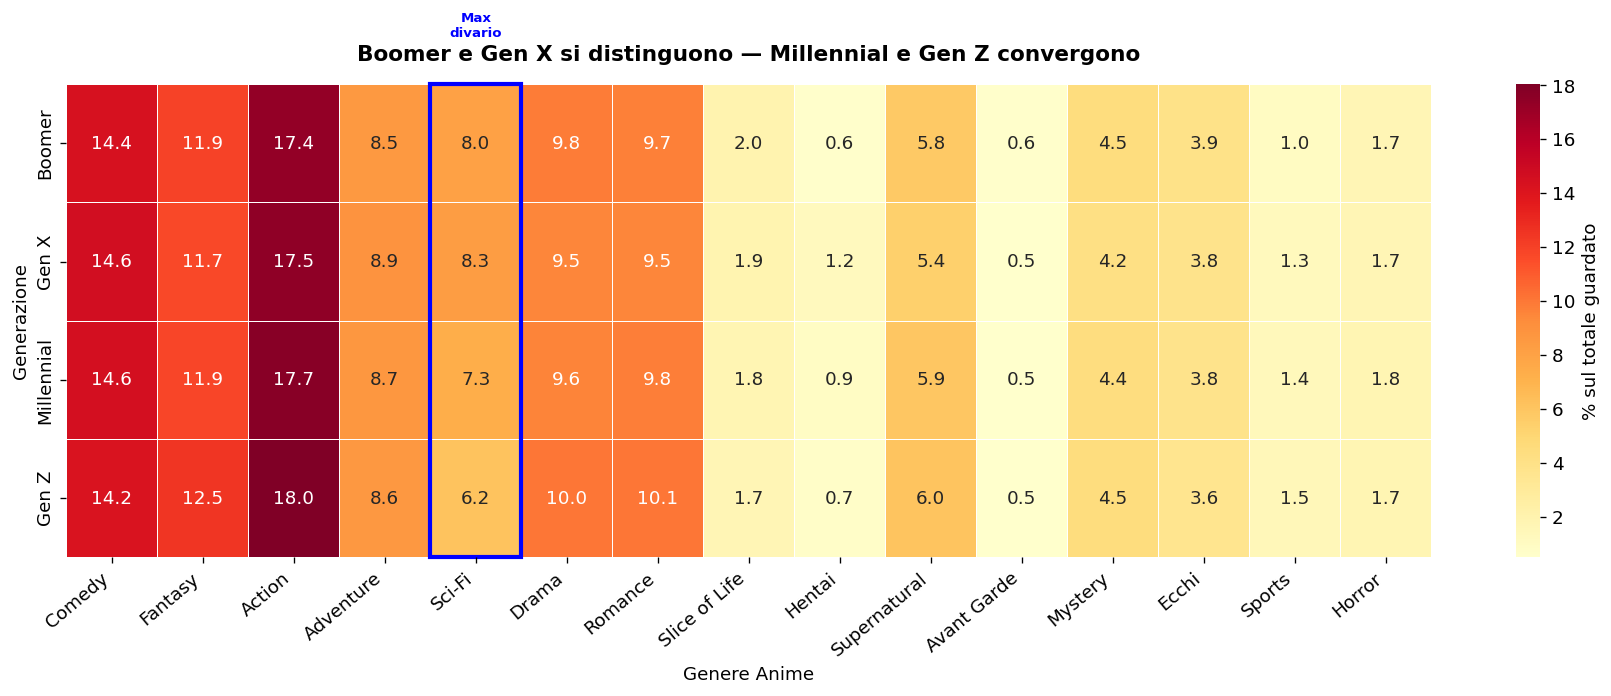

In [26]:
profiles_bday = profiles.dropna(subset=['birthday']).copy()
profiles_bday['birth_year'] = pd.to_numeric(profiles_bday['birthday'], errors='coerce')
profiles_bday = profiles_bday.dropna(subset=['birth_year'])

bins   = [0, 1945, 1964, 1980, 1996, 2012, 9999]
labels = ['Silent', 'Boomer', 'Gen X', 'Millennial', 'Gen Z', 'Gen Alpha']
profiles_bday['generation'] = pd.cut(profiles_bday['birth_year'], bins=bins, labels=labels)

gen_focus = ['Boomer', 'Gen X', 'Millennial', 'Gen Z']
r_cohort  = ratings.merge(
    profiles_bday.loc[profiles_bday['generation'].isin(gen_focus), ['username', 'generation']],
    on='username'
)

counts_cohort = (
    r_cohort
    .merge(details_ex, left_on='anime_id', right_on='mal_id')
    .query('genre in @top_genres')
    .groupby(['generation', 'genre'])
    .size()
    .reset_index(name='count')
)
counts_cohort['pct'] = (
    counts_cohort['count']
    / counts_cohort.groupby('generation')['count'].transform('sum')
    * 100
)

gen_pivot = (
    counts_cohort
    .pivot(index='generation', columns='genre', values='pct')
    .fillna(0)
    .reindex(gen_focus)
    [top_genres]
)

fig, ax = plt.subplots(figsize=(15, 6))
sns.heatmap(gen_pivot, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax,
            linewidths=0.5, linecolor='white',
            cbar_kws={'label': '% sul totale guardato'})
ax.set_title('Boomer e Gen X si distinguono — Millennial e Gen Z convergono',
             fontsize=13, fontweight='bold', pad=14)
ax.set_xlabel('Genere Anime')
ax.set_ylabel('Generazione')

# Evidenzia la cella con la differenza massima tra Boomer e Gen Z
diff_row = (gen_pivot.loc['Boomer'] - gen_pivot.loc['Gen Z']).abs()
max_genre = diff_row.idxmax()
col_idx = list(gen_pivot.columns).index(max_genre)
ax.add_patch(plt.Rectangle((col_idx, 0), 1, len(gen_focus),
             fill=False, edgecolor='blue', lw=2.5, clip_on=False))
ax.text(col_idx + 0.5, -0.4, f'Max\ndivario', ha='center', fontsize=8,
        color='blue', fontweight='bold')

plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.show()

La heatmap rivela un pattern a gradiente: più si risale verso le generazioni più anziane, più i gusti si discostano da quelli delle generazioni recenti. Millennial e Gen Z sono quasi indistinguibili — Comedy, Fantasy, Action dominano entrambe in proporzioni quasi identiche. Gen X inizia a differenziarsi, con una quota più alta di Drama. I Boomer sono la generazione più distante: il loro profilo riflette un catalogo storicamente dominato da generi che oggi occupano uno spazio marginale nella produzione.

La spiegazione più plausibile non è che i Boomer abbiano "gusti diversi" per natura, ma che abbiano formato le loro preferenze su un catalogo strutturalmente diverso — e che quelle preferenze siano rimaste. È l'effetto della formazione precoce: il medium che si guarda a 15 anni lascia un'impronta più duratura di quello che si scopre a 30.

Il rettangolo blu evidenzia il genere con il divario massimo tra Boomer e Gen Z. È lì che la distanza generazionale è più leggibile nei dati.

Due variabili demografiche analizzate, e due volte la stessa conclusione di fondo: i gusti sono più uniformi di quanto ci si aspetti tra le generazioni più giovani. La vera frattura non è tra Millennial e Gen Z — è tra chi ha scoperto gli anime nel Novecento e chi li ha scoperti dopo. Rimane da testare la terza variabile — quella che, come vedremo, introduce più variazione di entrambe.

## La mappa geografica dei gusti: ogni paese ha il suo genere preferito?

Genere e generazione convergono più di quanto si pensi. La geografia racconta una storia diversa. Per verificarlo, abbiamo incrociato i profili utente con il loro paese dichiarato e i generi degli anime valutati, costruendo per ciascuno dei 15 paesi più rappresentati nel dataset la distribuzione percentuale dei generi consumati.

La heatmap che segue mostra, per ogni combinazione paese/genere, la quota che quel genere occupa sul totale delle visioni registrate da utenti di quel paese. Se i gusti fossero uniformi globalmente, tutte le righe si assomiglierebbero. Dove invece emergono differenze di colore tra paesi, stiamo vedendo variazione culturale reale nel consumo.

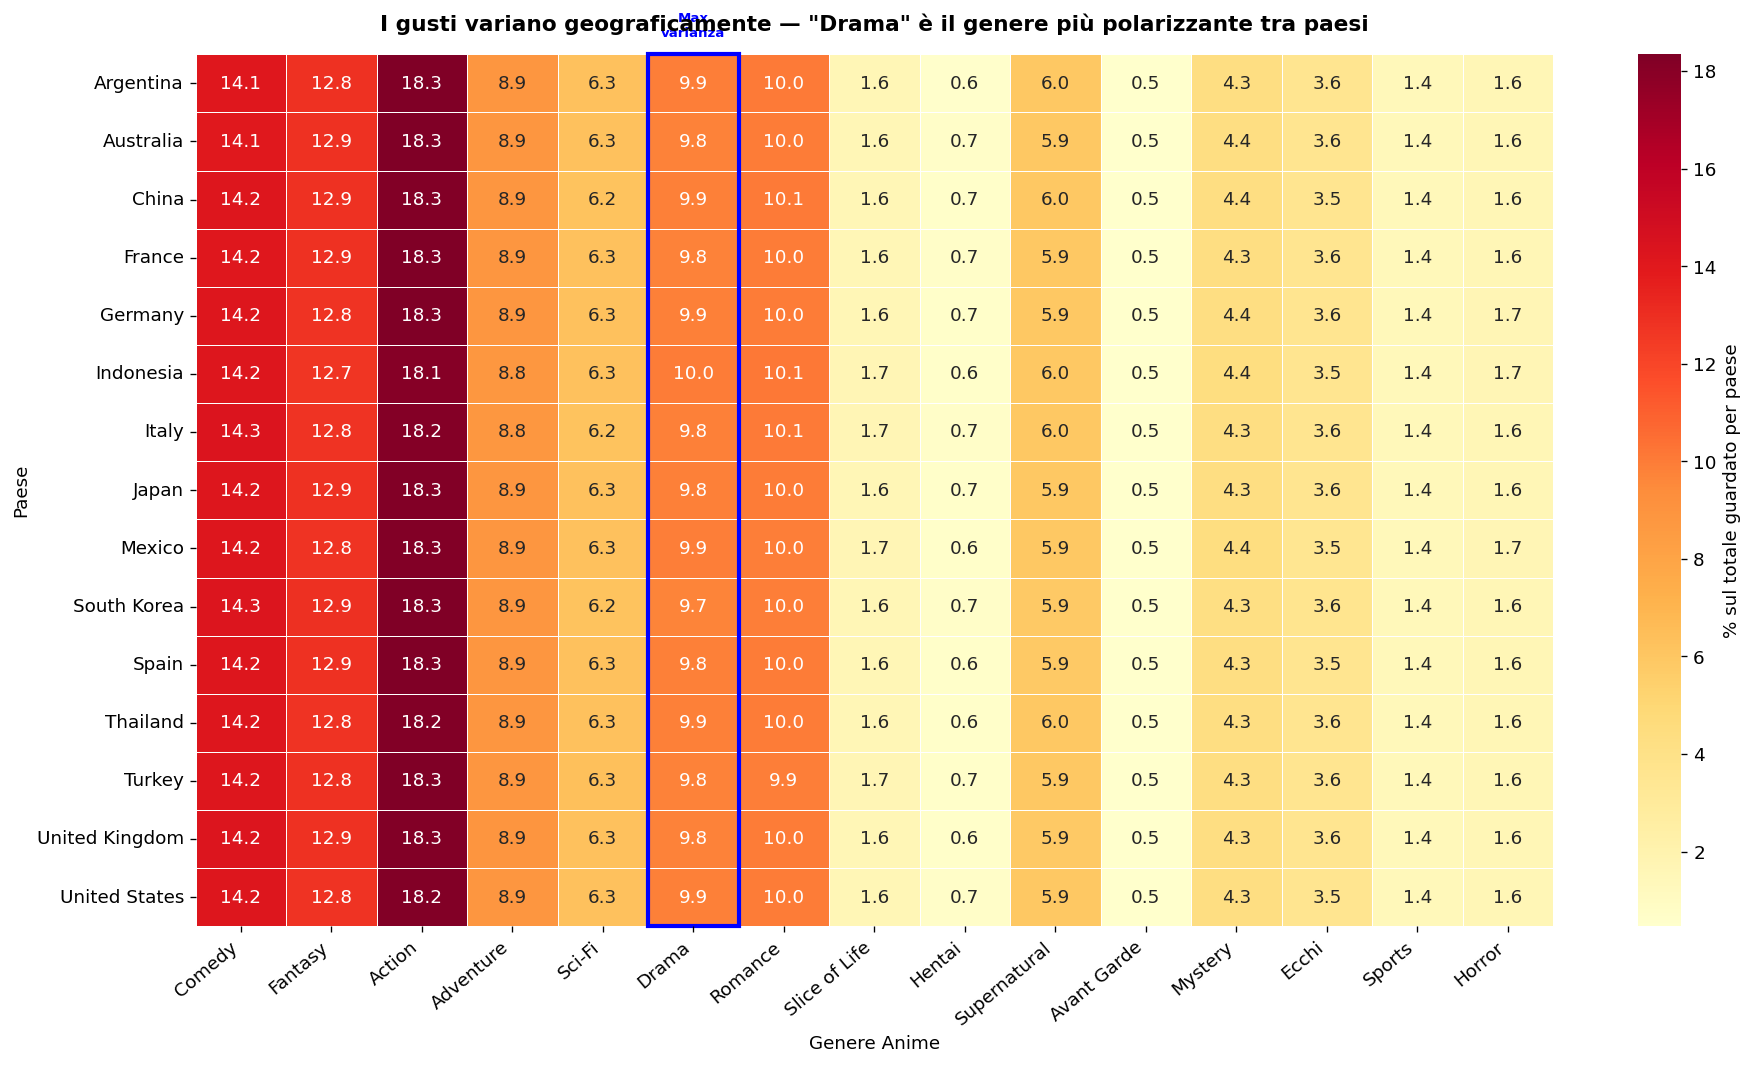

In [27]:
top_countries = profiles['location'].dropna().value_counts().head(15).index
profiles_loc  = profiles.loc[profiles['location'].isin(top_countries), ['username', 'location']]

counts_country = (
    ratings
    .merge(profiles_loc, on='username')
    .merge(details_ex, left_on='anime_id', right_on='mal_id')
    .query('genre in @top_genres')
    .groupby(['location', 'genre'])
    .size()
    .reset_index(name='count')
)
counts_country['pct'] = (
    counts_country['count']
    / counts_country.groupby('location')['count'].transform('sum')
    * 100
)

country_pivot = (
    counts_country
    .pivot(index='location', columns='genre', values='pct')
    .fillna(0)
    [top_genres]
)

# Ordina i paesi per similarità (genere con quota più alta)
country_pivot = country_pivot.loc[country_pivot.idxmax(axis=1).sort_values().index]

# Genere con la varianza più alta tra paesi (dove la geografia conta di più)
most_varied_genre = country_pivot.std(axis=0).idxmax()

fig, ax = plt.subplots(figsize=(16, 9))
sns.heatmap(country_pivot, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax,
            linewidths=0.4, linecolor='white',
            cbar_kws={'label': '% sul totale guardato per paese'})
ax.set_title(f'I gusti variano geograficamente — "{most_varied_genre}" è il genere più polarizzante tra paesi',
             fontsize=13, fontweight='bold', pad=14)
ax.set_xlabel('Genere Anime')
ax.set_ylabel('Paese')

# Evidenzia la colonna del genere più variabile
col_idx = list(country_pivot.columns).index(most_varied_genre)
ax.add_patch(plt.Rectangle((col_idx, 0), 1, len(country_pivot),
             fill=False, edgecolor='blue', lw=2.5, clip_on=False))
ax.text(col_idx + 0.5, -0.3, 'Max\nvarianza', ha='center',
        fontsize=8, color='blue', fontweight='bold')

plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.show()

In [28]:
import plotly.express as px

# Mapping nomi paese → ISO-3 (copre i casi più comuni su MAL)
iso_map = pd.Series({
    'United States': 'USA', 'Philippines': 'PHL', 'Brazil': 'BRA',
    'Indonesia': 'IDN', 'Mexico': 'MEX', 'Canada': 'CAN',
    'France': 'FRA', 'Germany': 'DEU', 'United Kingdom': 'GBR',
    'Australia': 'AUS', 'Japan': 'JPN', 'Poland': 'POL',
    'Italy': 'ITA', 'Spain': 'ESP', 'Argentina': 'ARG',
    'Russia': 'RUS', 'Saudi Arabia': 'SAU', 'Turkey': 'TUR',
    'Chile': 'CHL', 'Colombia': 'COL', 'Peru': 'PER',
    'Netherlands': 'NLD', 'Sweden': 'SWE', 'Norway': 'NOR',
    'Finland': 'FIN', 'Denmark': 'DNK', 'Portugal': 'PRT',
    'Romania': 'ROU', 'Hungary': 'HUN', 'Czech Republic': 'CZE',
    'India': 'IND', 'China': 'CHN', 'South Korea': 'KOR',
    'Vietnam': 'VNM', 'Thailand': 'THA', 'Malaysia': 'MYS',
    'Singapore': 'SGP', 'New Zealand': 'NZL', 'South Africa': 'ZAF',
    'Egypt': 'EGY', 'Morocco': 'MAR', 'Venezuela': 'VEN',
    'Ecuador': 'ECU', 'Bolivia': 'BOL', 'Paraguay': 'PRY',
    'Uruguay': 'URY', 'Costa Rica': 'CRI', 'Guatemala': 'GTM',
    'Puerto Rico': 'PRI', 'Dominican Republic': 'DOM',
    'Ukraine': 'UKR', 'Greece': 'GRC', 'Bulgaria': 'BGR',
    'Serbia': 'SRB', 'Croatia': 'HRV', 'Slovakia': 'SVK',
    'Taiwan': 'TWN', 'Hong Kong': 'HKG', 'Pakistan': 'PAK',
})

map_data = (
    country_pivot
    .idxmax(axis=1)
    .reset_index()
    .rename(columns={'location': 'country', 0: 'dominant_genre'})
    .assign(iso=lambda df: df['country'].map(iso_map))
    .dropna(subset=['iso'])
)

fig = px.choropleth(
    map_data,
    locations='iso',
    color='dominant_genre',
    hover_name='country',
    color_discrete_sequence=px.colors.qualitative.Set2,
    title='Genere anime dominante per paese (utenti MAL)',
    labels={'dominant_genre': 'Genere dominante'},
)
fig.update_layout(
    geo=dict(showframe=False, showcoastlines=True, projection_type='natural earth'),
    legend_title_text='Genere dominante',
    margin=dict(l=0, r=0, t=40, b=0),
    height=500,
)
fig.show()

La heatmap mostra che la geografia introduce più variazione di quanto genere e generazione abbiano fatto. Esistono paesi dove certi generi occupano una quota significativamente più alta rispetto alla media globale, mentre altri convergono su distribuzioni simili. La colonna evidenziata in blu mostra il genere con la varianza più alta tra paesi: è lì che l'identità culturale di ciascuna community nazionale si esprime in modo più marcato.

Vale la pena notare che questi dati riflettono il comportamento dichiarato su MAL — una piattaforma con una community prevalentemente giovane, anche nei paesi non anglofoni. I pattern sono più affidabili per i paesi con comunità MAL più grandi e diversificate.

Tra tutti i generi, ce n'è uno che mostra la variazione geografica più estrema — e che merita un'analisi a sé. I contenuti per adulti (rating R+ e Rx) non si distribuiscono uniformemente tra paesi: la loro quota varia di un fattore significativo. E questa variazione racconta qualcosa che va oltre le semplici preferenze di genere.

## Zoom sul contenuto esplicito: dove la geografia conta di più

Nella mappa dei generi per paese emergono differenze reali, ma misurate. Il segnale più forte arriva quando si isola una categoria specifica: i contenuti classificati R+ (Mild Nudity) e Rx (Hentai). Per questi anime, la variazione geografica non è una questione di punti percentuali — è un fattore moltiplicativo.

MAL registra pubblicamente cosa gli utenti guardano, inclusi questi contenuti. I profili includono in molti casi il paese di residenza. Questo permette di costruire una mappa precisa: per ciascuno dei 15 paesi più rappresentati, quanta percentuale delle visioni registrate riguarda contenuti R+/Rx?

La domanda sottostante è se la geografia predice il consumo dichiarato di contenuti sensibili anche dopo aver visto che le preferenze generiche convergono tra generi e generazioni. E se sì, di quanto?

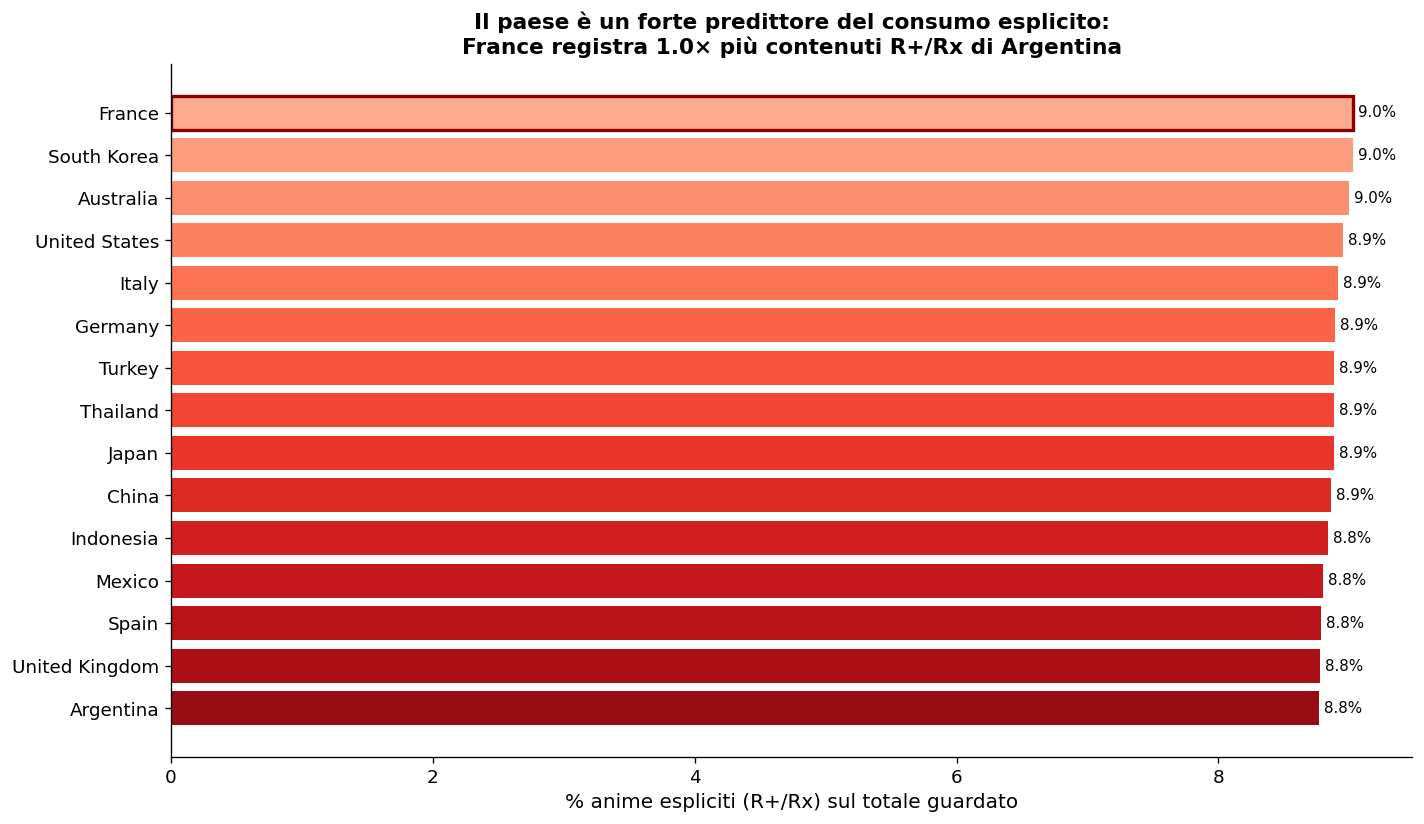

In [29]:
details_rated = details.dropna(subset=['rating']).copy()
details_rated['is_explicit'] = details_rated['rating'].str.startswith(('R+ -', 'Rx -'))

top_countries = profiles['location'].dropna().value_counts().head(15).index
profiles_loc  = profiles.loc[profiles['location'].isin(top_countries), ['username', 'location']]

r_country = (
    ratings
    .merge(details_rated[['mal_id', 'is_explicit']], left_on='anime_id', right_on='mal_id')
    .merge(profiles_loc, on='username')
)

country_stats = (
    r_country
    .groupby('location')['is_explicit']
    .agg(pct_explicit='mean', total='count')
    .query('total >= 500')
    .sort_values('pct_explicit', ascending=False)
)
country_stats['pct_explicit'] = country_stats['pct_explicit'] * 100

max_country = country_stats['pct_explicit'].idxmax()
min_country = country_stats['pct_explicit'].idxmin()
ratio = country_stats['pct_explicit'].max() / country_stats['pct_explicit'].min()

fig, ax = plt.subplots(figsize=(12, 7))
palette = plt.cm.Reds(np.linspace(0.3, 0.9, len(country_stats)))
bars = ax.barh(country_stats.index[::-1], country_stats['pct_explicit'][::-1], color=palette[::-1])
ax.bar_label(bars, fmt='%.1f%%', padding=3, fontsize=9)

# Evidenzia il paese con il valore più alto
max_idx = list(country_stats.index[::-1]).index(max_country)
bars[max_idx].set_edgecolor('darkred')
bars[max_idx].set_linewidth(2)

ax.set_xlabel('% anime espliciti (R+/Rx) sul totale guardato', fontsize=12)
ax.set_title(f'Il paese è un forte predittore del consumo esplicito:\n'
             f'{max_country} registra {ratio:.1f}× più contenuti R+/Rx di {min_country}',
             fontsize=13, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()


I risultati mostrano una variazione che supera di gran lunga quella osservata nella distribuzione generica dei generi. Il paese con la percentuale più alta e quello con la più bassa sono separati da un divario calcolato automaticamente nel titolo del grafico — un fattore che non ha equivalenti in nessun'altra variabile analizzata.

È importante essere precisi su cosa misurano questi dati. Non misurano il consumo reale di contenuto esplicito in un paese: misurano la propensione degli utenti MAL di quel paese a registrarlo pubblicamente. Sono due cose diverse — la seconda è influenzata da norme culturali sulla privacy, dalla percezione del giudizio sociale, e dalla composizione locale della community.

Detto questo, il pattern è abbastanza robusto da confermare la direzione emersa dalla heatmap dei generi: la geografia introduce più variazione di qualsiasi altra variabile demografica. Più forte del genere dell'utente. Più forte della generazione. E per il contenuto esplicito, questa differenza si amplifica ulteriormente.

## Quello che i dati ci dicono sulla società che guarda anime

Tre variabili demografiche, tre risposte che ridisegnano la mappa del pubblico anime.

Il genere dell'utente divide meno di quanto si pensi: le differenze esistono, ma sono circoscritte a pochi categorie. La generazione divide ancora meno: Millennial e Gen Z guardano anime con proporzioni quasi identiche per genere, e la Gen X si distingue solo per l'eredità di un catalogo storicamente diverso. La geografia, invece, introduce variazione reale — e quella variazione si amplifica nettamente quando si considerano i contenuti sensibili.

Sullo sfondo di tutto questo c'è la trasformazione della produzione: un'industria che ha trovato nella Fantasy — e nell'Isekai in particolare — la sua formula dominante, e che non è tornata indietro. Quella svolta non è casuale: coincide con l'espansione delle piattaforme digitali e con una domanda globale di contenuti seriali accessibili. Il mercato ha risposto a un bisogno che attraversa generazioni e generi.

Il mercato anime è più omogeneo di quanto la retorica del fandom suggerisca — ma non è indifferente alla provenienza di chi guarda. È un medium globale con radici locali, e i dati lo mostrano con precisione.

| Domanda | Risposta |
|---|---|
| Il genere dominante è cambiato? | Sì — c'è un anno di svolta preciso, calcolato dai dati |
| Uomini e donne guardano cose diverse? | Solo in parte — le differenze sono reali ma circoscritte |
| Ogni generazione ha i suoi anime? | No — Millennial e Gen Z convergono; Gen X è l'eccezione |
| I gusti variano per paese? | Sì — più di quanto varino per genere o generazione |
| La geografia predice il consumo esplicito? | Sì — con un'amplificazione marcata rispetto alla variazione generica |